
# 11 - Model Selection

Este notebook compara varios modelos para predecir `produccion_kg` usando el dataset:

`data/processed/training_dataset.parquet`

## Objetivo
Seleccionar un modelo base sólido antes de pasar a tuning fino.

## Qué hace
- carga el dataset
- limpia columnas no aptas para entrenamiento
- separa variables numéricas y categóricas
- hace un **split temporal**
- entrena varios modelos base
- compara métricas
- muestra importancias del mejor modelo compatible


## 1. Importaciones

In [90]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor



## 2. Carga del dataset

Se intenta primero exactamente la ruta pedida por el usuario y luego algunas rutas alternativas comunes.


In [91]:

def resolve_path() -> Path:
    candidates = [
        Path("../data/processed/training_dataset.parquet"),
        Path("./data/processed/training_dataset.parquet"),
        Path("/mnt/data/data/processed/training_dataset.parquet"),
        Path("/mnt/data/training_dataset.parquet"),
        Path("./outputs/training_dataset.parquet"),
        Path("./training_dataset.parquet"),
    ]
    for p in candidates:
        if p.exists():
            return p.resolve()
    raise FileNotFoundError("No se encontró training_dataset.parquet en las rutas esperadas.")

DATA_PATH = resolve_path()
print("Dataset encontrado en:", DATA_PATH)

df = pd.read_parquet(DATA_PATH)
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()

print("Shape:", df.shape)
display(df.head())


Dataset encontrado en: /Users/josemanuelromoperedo/Desktop/ProyectoGranja/data/processed/training_dataset.parquet
Shape: (18345, 52)


,cow_id,date,ordenos_dia,produccion_kg,duracion_total_min,di_mean,dd_mean,td_mean,ti_mean,ubre,...,THI,heat_stress_flag,dow_sin,dow_cos,doy_sin,doy_cos,carbs_ratio,protein_ratio,fiber_ratio,is_pregnant
0,1204,2022-06-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,67.799947,0,-0.781831,0.623490,0.455907,-0.890028,NaN,NaN,NaN,0
1,1204,2022-06-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,66.428090,0,0.974928,-0.222521,0.409356,-0.912375,NaN,NaN,NaN,0
2,1204,2022-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,66.204862,0,-0.433884,-0.900969,0.025818,-0.999667,NaN,NaN,NaN,0
3,1204,2022-08-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,62.226701,0,0.000000,1.000000,-0.680773,-0.732494,NaN,NaN,NaN,0
4,1204,2022-09-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,60.098584,0,0.781831,0.623490,-0.996659,-0.081676,NaN,NaN,NaN,0



## 3. Revisión rápida

Se define `produccion_kg` como target y se eliminan filas sin target.


In [92]:

TARGET = "produccion_kg"

if TARGET not in df.columns:
    raise ValueError(f"No existe la columna target: {TARGET}")

df = df.dropna(subset=[TARGET]).copy()

print("Shape después de quitar target nulo:", df.shape)
print("Rango de fechas:", df["date"].min(), "->", df["date"].max())
print("Vacas únicas:", df["cow_id"].nunique() if "cow_id" in df.columns else "N/A")


Shape después de quitar target nulo: (9814, 52)
Rango de fechas: 2025-01-01 00:00:00 -> 2025-09-30 00:00:00
Vacas únicas: 65



## 4. Limpieza mínima previa al modelado

### Decisiones
- `date` no se usa directamente como feature cruda.
- columnas de texto libres o ids de archivo no se usan.
- columnas categóricas pequeñas sí se pueden conservar.


In [93]:

drop_cols = [
    "date",           # se usa para split temporal, no como input crudo
    "source_file",    # metadata
    "raw_event_text",
    "event_types",
    "diagnosis_text",
    "medication_text",
    "treatment_text",
    "ordenos_dia",
    "di_mean",
    "dd_mean",
    "ti_mean",
    "td_mean",
    "duracion_total_min",
    "cow_id"
]

drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=[TARGET] + drop_cols, errors="ignore").copy()
y = df[TARGET].copy()

print("Shape X:", X.shape)
display(pd.DataFrame({
    "column": X.columns,
    "dtype": [str(X[c].dtype) for c in X.columns]
}).head(100))


Shape X: (9814, 43)


,column,dtype
0,ubre,float64
1,ms,str
2,rumia_min,float64
3,days_in_milk,float64
4,last_calving,datetime64[us]
5,mastitis_flag,float64
6,digestive_flag,float64
7,vaccine_flag,float64
8,reproductive_flag,float64
9,abortion_flag,float64



## 5. Split temporal

No se usa split aleatorio porque esto es una serie temporal por vaca.
Se entrena con el pasado y se evalúa con el futuro.


In [94]:

dates = df["date"].sort_values().dropna().unique()
split_idx = int(len(dates) * 0.8)
split_date = dates[split_idx]

train_mask = df["date"] < split_date
test_mask = df["date"] >= split_date

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Split date:", split_date)
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Split date: 2025-06-09 00:00:00
Train: (9207, 43) (9207,)
Test : (607, 43) (607,)



## 6. Tipos de variables y preprocesamiento

- Numéricas: imputación por mediana
- Categóricas: imputación por moda + one-hot encoding
- Escalado solo para el modelo lineal


In [95]:

numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

print("Numéricas:", len(numeric_cols))
print("Categóricas:", len(categorical_cols))
print("Primeras categóricas:", categorical_cols[:20])

numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


Numéricas: 41
Categóricas: 2
Primeras categóricas: ['ms', 'last_calving']



## 7. Modelos candidatos

Se comparan modelos simples pero fuertes como baseline:
- Ridge
- Random Forest
- Extra Trees
- HistGradientBoosting


In [96]:

models = {
    "Ridge": Pipeline(steps=[
        ("preprocessor", preprocessor_scaled),
        ("model", Ridge(alpha=1.0))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "ExtraTrees": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", ExtraTreesRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "HistGradientBoosting": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=8,
            max_iter=300,
            random_state=42
        ))
    ]),
}


## 8. Entrenamiento y evaluación

In [97]:

results = []

for name, pipe in models.items():
    print(f"Entrenando {name} ...")
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append({
        "model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)


Entrenando Ridge ...
Entrenando RandomForest ...
Entrenando ExtraTrees ...
Entrenando HistGradientBoosting ...


,model,RMSE,MAE,R2
0,ExtraTrees,7.797535,6.162754,0.498170
1,Ridge,7.844041,6.210870,0.492167
2,RandomForest,7.847477,6.159080,0.491722
3,HistGradientBoosting,7.902227,6.256211,0.484605



## 9. Visualización de métricas

Se ordenan por RMSE porque es una métrica muy interpretable en el mismo espacio del target.


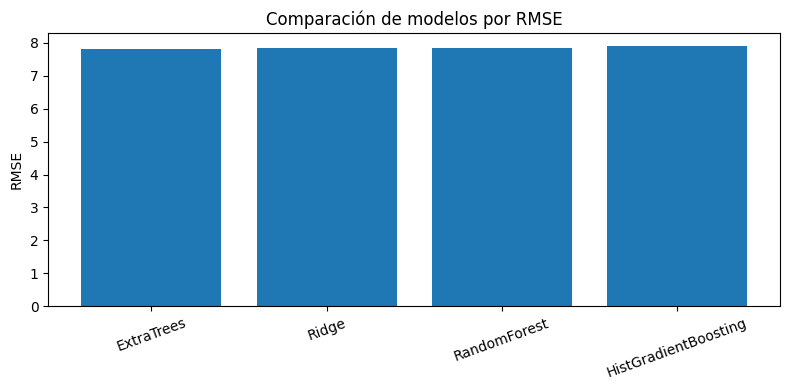

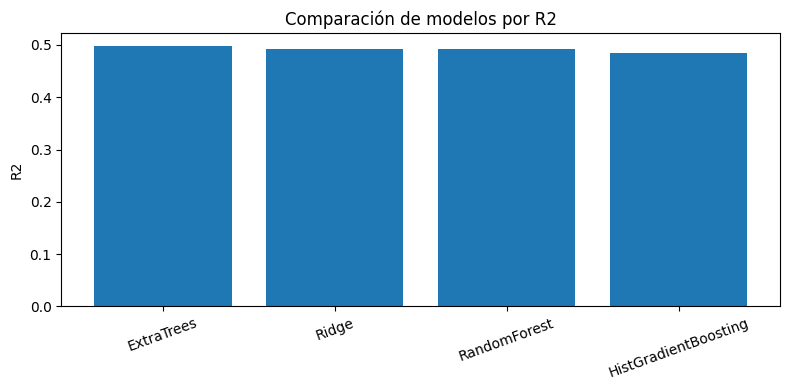

In [98]:

plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["RMSE"])
plt.title("Comparación de modelos por RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["R2"])
plt.title("Comparación de modelos por R2")
plt.ylabel("R2")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



## 10. Mejor modelo

Se selecciona el mejor por RMSE y se vuelve a entrenar para análisis adicional.


In [99]:

best_model_name = results_df.iloc[0]["model"]
best_pipe = models[best_model_name]

best_pipe.fit(X_train, y_train)
best_pred = best_pipe.predict(X_test)

print("Mejor modelo:", best_model_name)
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("MAE :", mean_absolute_error(y_test, best_pred))
print("R2  :", r2_score(y_test, best_pred))


Mejor modelo: ExtraTrees
RMSE: 7.797534656719856
MAE : 6.162753891351342
R2  : 0.4981704644346109



## 11. Predicción vs real

Esto ayuda a ver si el modelo sigue la tendencia general o está muy sesgado.


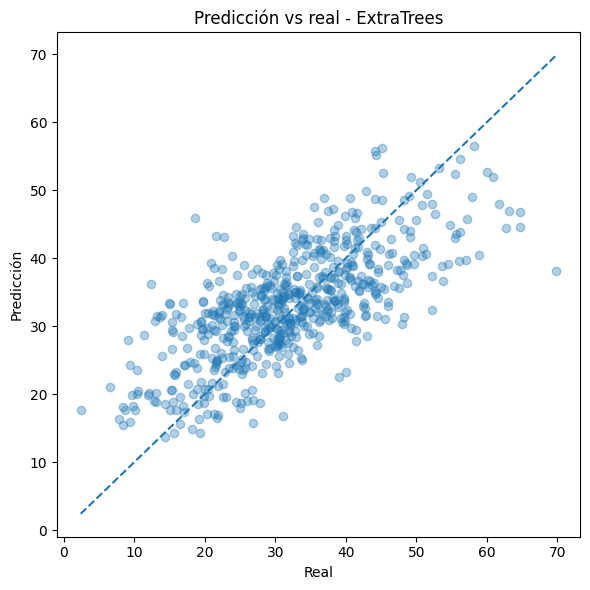

In [100]:

compare_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": best_pred
})

plt.figure(figsize=(6, 6))
plt.scatter(compare_df["y_true"], compare_df["y_pred"], alpha=0.35)
lims = [
    min(compare_df["y_true"].min(), compare_df["y_pred"].min()),
    max(compare_df["y_true"].max(), compare_df["y_pred"].max()),
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title(f"Predicción vs real - {best_model_name}")
plt.tight_layout()
plt.show()



## 12. Importancia de variables

Solo se calcula para modelos basados en árboles que exponen `feature_importances_`.


,importance
num__produccion_roll_mean_3,0.446457
num__produccion_lag_1,0.104713
num__days_since_calving_flag,0.050340
num__days_since_insemination_flag,0.041185
num__doy_cos,0.030640
num__dow_sin,0.030349
num__doy_sin,0.029281
num__dow_cos,0.028852
num__days_since_abortion_flag,0.028797
num__THI,0.028333


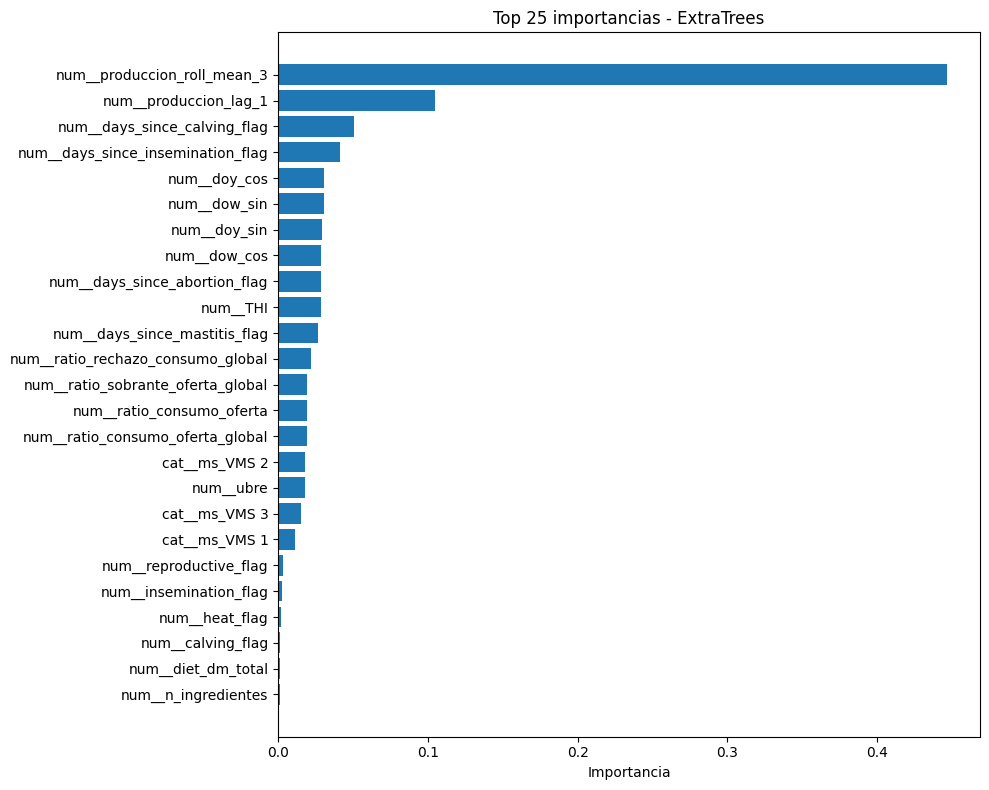

In [101]:

tree_like = {"RandomForest", "ExtraTrees"}

if best_model_name in tree_like:
    pre = best_pipe.named_steps["preprocessor"]
    model = best_pipe.named_steps["model"]

    feature_names = pre.get_feature_names_out()
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)

    display(importances.head(30).to_frame("importance"))

    plt.figure(figsize=(10, 8))
    top = importances.head(25).sort_values()
    plt.barh(top.index, top.values)
    plt.title(f"Top 25 importancias - {best_model_name}")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()
else:
    print("El mejor modelo no expone feature_importances_ directamente.")


In [102]:
from sklearn.inspection import permutation_importance

print("Calculando permutation importance...")

perm = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

display(perm_importance.head(25).to_frame("importance"))

Calculando permutation importance...


,importance
produccion_roll_mean_3,1.198213e+00
produccion_lag_1,1.875102e-01
ms,5.086417e-02
days_since_mastitis_flag,2.083801e-02
days_since_insemination_flag,1.870739e-02
days_since_abortion_flag,1.672035e-02
days_since_calving_flag,1.631640e-02
ubre,3.531924e-03
heat_flag,2.459189e-03
dow_sin,1.366444e-03


In [103]:
from sklearn.inspection import permutation_importance

all_importances = {}

for name, pipe in models.items():
    print(f"Permutation importance: {name}")

    pipe.fit(X_train, y_train)

    perm = permutation_importance(
        pipe,
        X_test,
        y_test,
        n_repeats=3,
        random_state=42,
        n_jobs=-1
    )

    imp = pd.Series(
        perm.importances_mean,
        index=X_test.columns
    ).sort_values(ascending=False)

    all_importances[name] = imp

imp_df = pd.DataFrame(all_importances)
imp_df["mean_importance"] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values("mean_importance", ascending=False)

display(imp_df.head(20))

Permutation importance: Ridge
Permutation importance: RandomForest
Permutation importance: ExtraTrees
Permutation importance: HistGradientBoosting


,Ridge,RandomForest,ExtraTrees,HistGradientBoosting,mean_importance
produccion_roll_mean_3,1.590569,1.474234,1.206050,1.354017,1.406217
produccion_lag_1,0.259961,0.241224,0.191926,0.288644,0.245439
ms,0.009564,0.008092,0.043689,0.011118,0.018116
days_since_mastitis_flag,-0.000173,0.016379,0.017253,0.024867,0.014581
days_since_insemination_flag,0.011492,0.008634,0.019417,0.015800,0.013836
days_since_calving_flag,-0.002229,0.021431,0.017383,0.018048,0.013658
days_since_abortion_flag,0.006275,0.013085,0.017185,0.015976,0.013130
ubre,0.002319,0.002253,0.004590,0.007447,0.004152
dryoff_related_flag,0.003353,0.000002,0.000092,0.000000,0.000862
heat_flag,-0.000306,0.000210,0.002543,0.000370,0.000704



## 13. Guardado de resultados

Se guarda:
- tabla de métricas
- predicciones del mejor modelo


In [104]:

out_dir = Path("./outputs")
out_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(out_dir / "model_selection_results.csv", index=False)

pred_out = df.loc[test_mask, ["cow_id", "date", TARGET]].copy()
pred_out["prediction"] = best_pred
pred_out.to_csv(out_dir / "best_model_predictions.csv", index=False)

print("Guardado:")
print((out_dir / "model_selection_results.csv").resolve())
print((out_dir / "best_model_predictions.csv").resolve())


Guardado:
/Users/josemanuelromoperedo/Desktop/ProyectoGranja/notebooks/outputs/model_selection_results.csv
/Users/josemanuelromoperedo/Desktop/ProyectoGranja/notebooks/outputs/best_model_predictions.csv



## 14. Conclusión

Este notebook no busca el mejor modelo final ajustado, sino una **selección inicial razonable**.

### Siguiente paso recomendado
Tomar el mejor modelo y hacer:
- tuning de hiperparámetros
- validación temporal más estricta
- análisis por vaca o por etapa de lactancia
